In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Carga de datos ──────────────────────────────────────────────────────────
eval_dir = Path("./evaluations")
csv_files = sorted(eval_dir.glob("eval_checklist_*.csv"))
csv_files = [f for f in csv_files if "template" not in f.name]

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

# ── Orden de degradación inferido desde los datos ───────────────────────────
def _sort_key(name):
    if name == "base":
        return -1
    m = re.match(r"layercut_(\d+)", name)
    return int(m.group(1)) if m else 9999

model_order = sorted(df["modelo"].unique().tolist(), key=_sort_key)

def _label(name):
    if name == "base":
        return "Base"
    m = re.match(r"layercut_(\d+)", name)
    return f"LC-{m.group(1)}" if m else name

model_labels = [_label(m) for m in model_order]

# ── Colores: base fijo, layercuts desde colormap ────────────────────────────
_cmap = plt.cm.tab10
COLORS = {}
_lc_idx = 0
for m in model_order:
    if m == "base":
        COLORS[m] = "#2196F3"
    else:
        COLORS[m] = _cmap(_lc_idx % 10)
        _lc_idx += 1

config_types  = ["training", "no_visto", "stress"]
config_labels = {"training": "Training", "no_visto": "No visto", "stress": "Stress"}
CONFIG_COLORS = {"training": "#42A5F5", "no_visto": "#66BB6A", "stress": "#EF5350"}

print(f"Modelos detectados ({len(model_order)}): {model_order}")
print(f"Etiquetas: {model_labels}")
print(f"Total filas: {len(df)}")
df.head(3)

Modelos detectados (17): ['base', 'layercut_0', 'layercut_1', 'layercut_2', 'layercut_3', 'layercut_4', 'layercut_5', 'layercut_6', 'layercut_7', 'layercut_8', 'layercut_9', 'layercut_10', 'layercut_11', 'layercut_12', 'layercut_13', 'layercut_14', 'layercut_15']
Etiquetas: ['Base', 'LC-0', 'LC-1', 'LC-2', 'LC-3', 'LC-4', 'LC-5', 'LC-6', 'LC-7', 'LC-8', 'LC-9', 'LC-10', 'LC-11', 'LC-12', 'LC-13', 'LC-14', 'LC-15']
Total filas: 255


,test_id,modelo,bloques_desactivados,intento,tipo_configuracion,layout_id,fuente,starBlackPos,starOrangePos,cubeBlackPos,...,cubo_naranja_agarre,cubo_naranja_destino,finalizacion_limpia,puntuacion_bruta,puntuacion_normalizada,exito_completo,modo_fallo,objeto_fallo,fase_fallo,notas
0,E-01,base,NaN,1,training,manual,manual,A1,A3,B1,...,1.0,1.0,1,9,1.00,1.0,ninguno,ninguno,ninguna,NaN
1,E-01,base,NaN,2,training,manual,manual,A1,A3,B1,...,1.0,0.0,0,3,0.33,0.0,bloqueo,cubo_negro,aproximacion,NaN
2,E-01,base,NaN,3,training,manual,manual,A1,A3,B1,...,1.0,1.0,1,9,1.00,1.0,ninguno,ninguno,ninguna,NaN


/tmp/ipykernel_22151/2295243472.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=10)


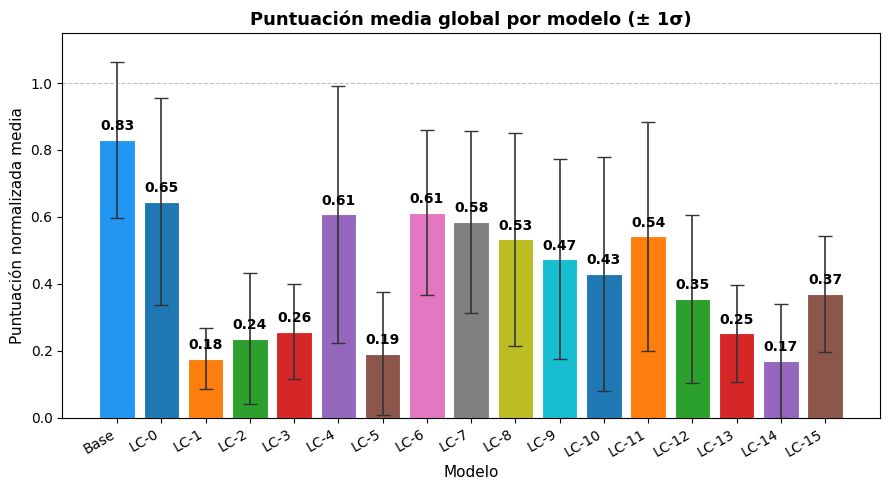

In [2]:
# ── 1. Puntuación media global por modelo ───────────────────────────────────
global_stats = (
    df.groupby("modelo")["puntuacion_normalizada"]
    .agg(["mean", "std", "count"])
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    global_stats.index,
    global_stats["mean"],
    yerr=global_stats["std"],
    capsize=5,
    color=[COLORS[m] for m in global_stats.index],
    edgecolor="white",
    linewidth=0.8,
    error_kw=dict(elinewidth=1.2, ecolor="#333"),
)
for bar, val in zip(bars, global_stats["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Puntuación normalizada media", fontsize=11)
ax.set_title("Puntuación media global por modelo (± 1σ)", fontsize=13, fontweight="bold")
ax.set_xlabel("Modelo", fontsize=11)
ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

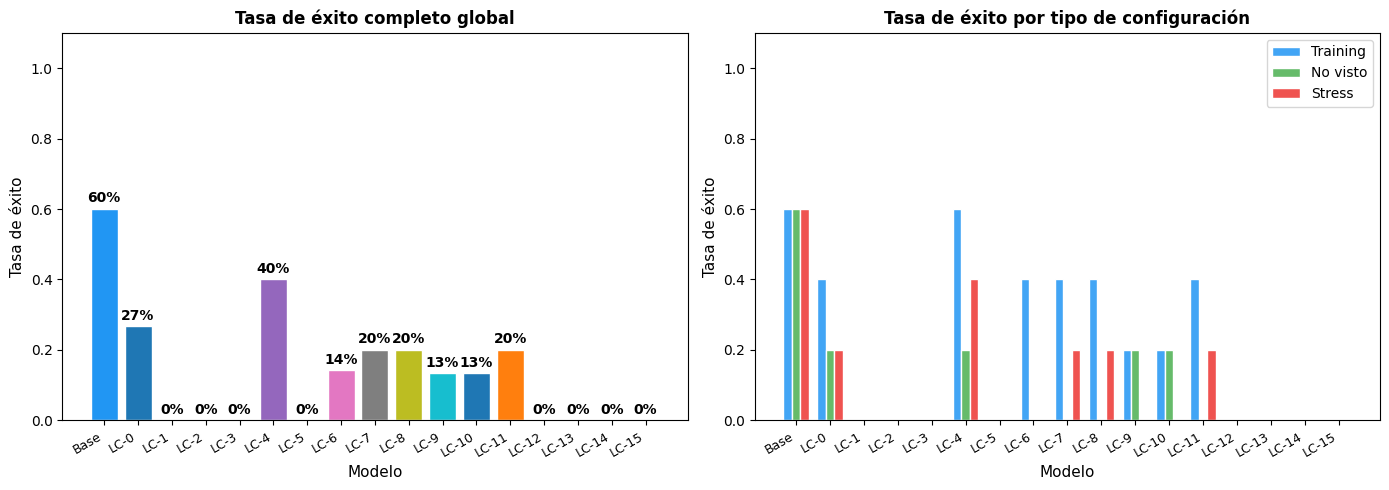

In [3]:
# ── 2. Tasa de éxito completo (global y por tipo de configuración) ───────────
success_global = (
    df.groupby("modelo")["exito_completo"].mean().reindex(model_order)
)
success_by_cfg = (
    df.groupby(["modelo", "tipo_configuracion"])["exito_completo"]
    .mean()
    .unstack("tipo_configuracion")
    .reindex(model_order)[config_types]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Global
bars = axes[0].bar(
    range(len(model_order)), success_global.values,
    color=[COLORS[m] for m in success_global.index], edgecolor="white"
)
for bar, val in zip(bars, success_global.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xticks(range(len(model_order)))
axes[0].set_xticklabels(model_labels, rotation=30, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Tasa de éxito", fontsize=11)
axes[0].set_title("Tasa de éxito completo global", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Modelo", fontsize=11)

# Por tipo de configuración
x = np.arange(len(model_order))
width = 0.25
for i, cfg in enumerate(config_types):
    vals = success_by_cfg[cfg].fillna(0).values
    axes[1].bar(x + (i - 1) * width, vals, width,
                label=config_labels[cfg], color=CONFIG_COLORS[cfg], edgecolor="white")

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels, rotation=30, ha="right", fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Tasa de éxito", fontsize=11)
axes[1].set_title("Tasa de éxito por tipo de configuración", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].set_xlabel("Modelo", fontsize=11)

plt.tight_layout()
plt.show()

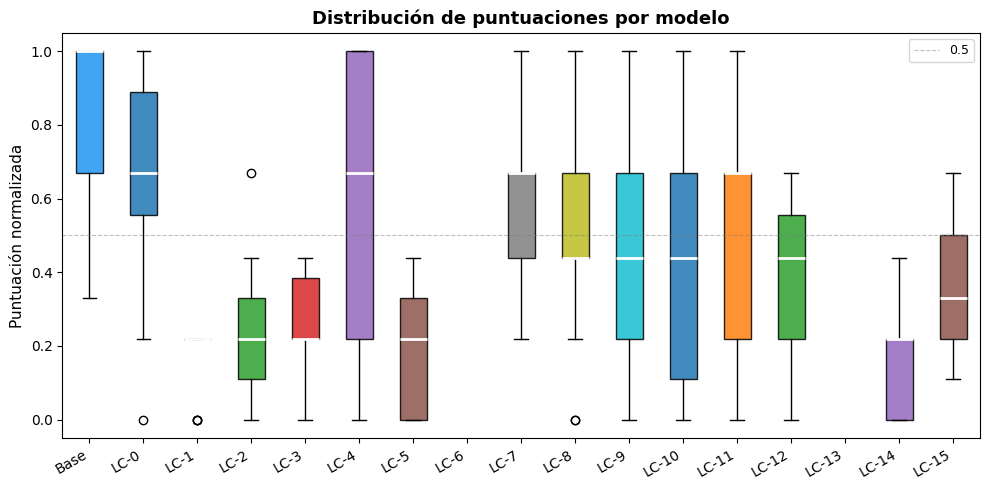

In [4]:
# ── 3. Distribución de puntuaciones (boxplot) ────────────────────────────────
data_by_model = [
    df[df["modelo"] == m]["puntuacion_normalizada"].values
    for m in model_order
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_model, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2))
for patch, model in zip(bp["boxes"], model_order):
    patch.set_facecolor(COLORS[model])
    patch.set_alpha(0.85)

ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Puntuación normalizada", fontsize=11)
ax.set_title("Distribución de puntuaciones por modelo", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, label="0.5")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

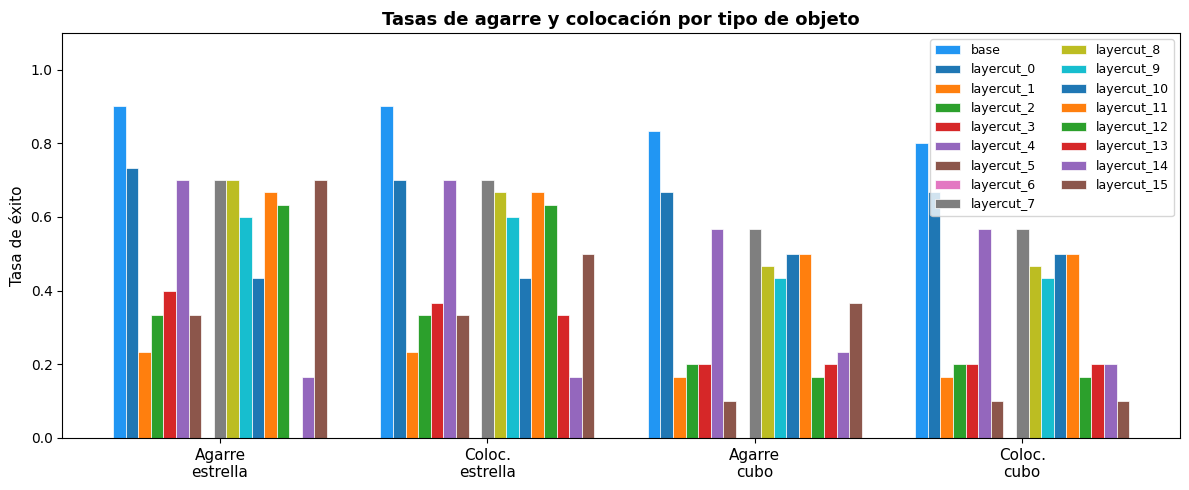

In [5]:
# ── 4. Tasas de agarre y colocación por objeto ───────────────────────────────
task_cols = {
    "Agarre\nestrella": ["estrella_negra_agarre", "estrella_naranja_agarre"],
    "Coloc.\nestrella": ["estrella_negra_destino", "estrella_naranja_destino"],
    "Agarre\ncubo":     ["cubo_negro_agarre", "cubo_naranja_agarre"],
    "Coloc.\ncubo":     ["cubo_negro_destino", "cubo_naranja_destino"],
}

rates = {}
for label, cols in task_cols.items():
    rates[label] = {
        m: df[df["modelo"] == m][cols].values.mean()
        for m in model_order
    }
rates_df = pd.DataFrame(rates, index=model_order)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rates_df.columns))
n = len(model_order)
width = 0.8 / n
for i, model in enumerate(model_order):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, rates_df.loc[model].values, width,
           label=model, color=COLORS[model], edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(rates_df.columns, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Tasa de éxito", fontsize=11)
ax.set_title("Tasas de agarre y colocación por tipo de objeto", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

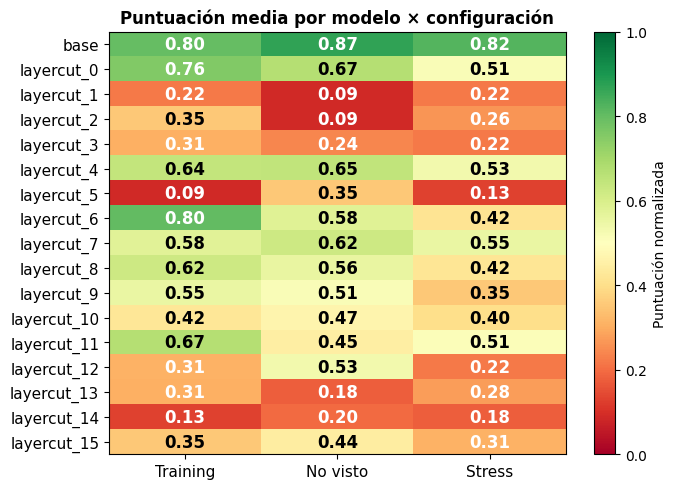

In [6]:
# ── 5. Puntuación media por modelo y tipo de configuración (heatmap) ─────────
heat = (
    df.groupby(["modelo", "tipo_configuracion"])["puntuacion_normalizada"]
    .mean()
    .unstack("tipo_configuracion")
    .reindex(model_order)[config_types]
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Puntuación normalizada")

ax.set_xticks(range(len(config_types)))
ax.set_xticklabels([config_labels[c] for c in config_types], fontsize=11)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=11)
ax.set_title("Puntuación media por modelo × configuración", fontsize=12, fontweight="bold")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        color = "black" if 0.35 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

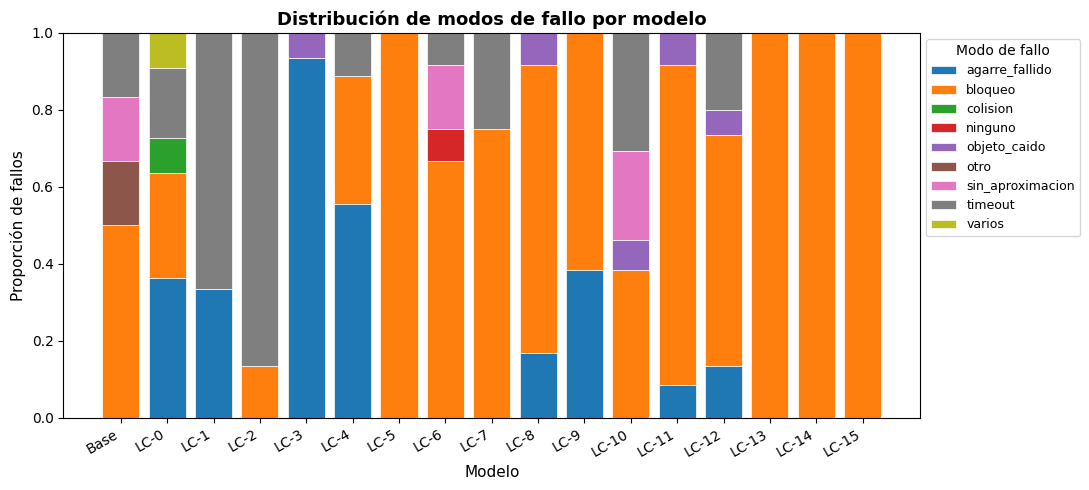

In [7]:
# ── 6. Modos de fallo por modelo (stacked bar) ───────────────────────────────
failed = df[df["exito_completo"] == 0].copy()
fail_counts = (
    failed.groupby(["modelo", "modo_fallo"])
    .size()
    .unstack(fill_value=0)
    .reindex(model_order)
)
fail_pct = fail_counts.div(fail_counts.sum(axis=1), axis=0).fillna(0)

palette = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(model_order))
for i, col in enumerate(fail_pct.columns):
    ax.bar(range(len(model_order)), fail_pct[col].values, bottom=bottom,
           label=col, color=palette[i % len(palette)], edgecolor="white", linewidth=0.5)
    bottom += fail_pct[col].values

ax.set_xticks(range(len(model_order)))
ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Proporción de fallos", fontsize=11)
ax.set_title("Distribución de modos de fallo por modelo", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, title="Modo de fallo")
ax.set_xlabel("Modelo", fontsize=11)
plt.tight_layout()
plt.show()

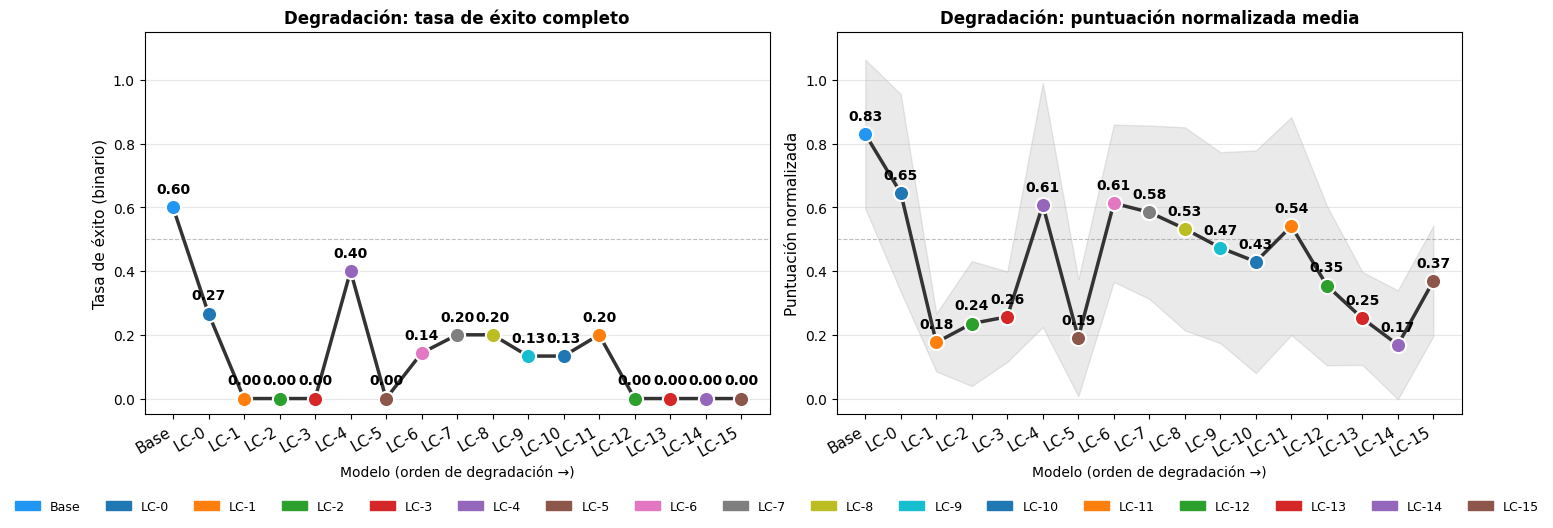

In [8]:
# ── 7. Curva de degradación: éxito global y parcial ─────────────────────────
x = np.arange(len(model_order))

success_global = df.groupby("modelo")["exito_completo"].mean().reindex(model_order).values
score_global   = df.groupby("modelo")["puntuacion_normalizada"].mean().reindex(model_order).values
score_std      = df.groupby("modelo")["puntuacion_normalizada"].std().reindex(model_order).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, values, std, title, ylabel, show_std in [
    (axes[0], success_global, None,      "Degradación: tasa de éxito completo",       "Tasa de éxito (binario)", False),
    (axes[1], score_global,   score_std, "Degradación: puntuación normalizada media",  "Puntuación normalizada",  True),
]:
    ax.plot(x, values, marker="o", markersize=9, linewidth=2.5, color="#333", zorder=3)
    for i, (m, v) in enumerate(zip(model_order, values)):
        ax.scatter(i, v, s=120, color=COLORS[m], zorder=4, edgecolors="white", linewidths=1.5)
    if show_std:
        ax.fill_between(x, values - std, values + std, alpha=0.12, color="#555")
    for i, v in enumerate(values):
        ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=11)
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel("Modelo (orden de degradación →)", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(axis="y", alpha=0.3)

patches = [mpatches.Patch(color=COLORS[m], label=lbl)
           for m, lbl in zip(model_order, model_labels)]
fig.legend(handles=patches, loc="lower center", ncol=len(model_order),
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

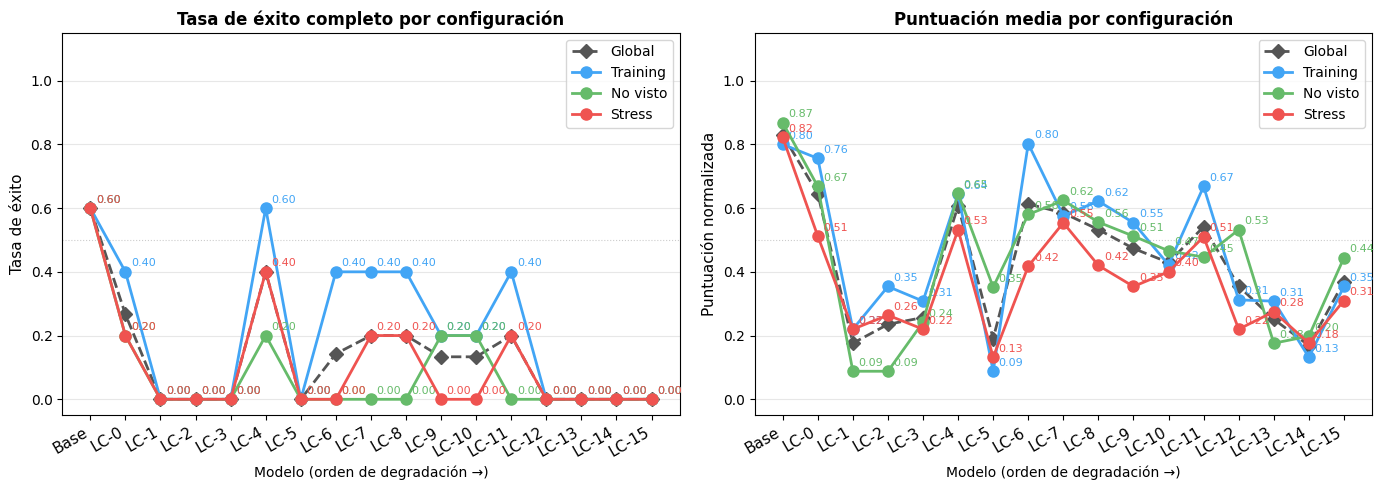

In [9]:
# ── 8. Curva de degradación por tipo de configuración ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, metric, title, ylabel in [
    (axes[0], "exito_completo",         "Tasa de éxito completo por configuración",   "Tasa de éxito"),
    (axes[1], "puntuacion_normalizada", "Puntuación media por configuración",          "Puntuación normalizada"),
]:
    global_vals = df.groupby("modelo")[metric].mean().reindex(model_order).values
    ax.plot(x, global_vals, marker="D", markersize=7, linewidth=2,
            color="#555", linestyle="--", label="Global", zorder=2)
    for cfg in config_types:
        vals = (
            df[df["tipo_configuracion"] == cfg]
            .groupby("modelo")[metric]
            .mean()
            .reindex(model_order)
            .values
        )
        ax.plot(x, vals, marker="o", markersize=8, linewidth=2,
                color=CONFIG_COLORS[cfg], label=config_labels[cfg], zorder=3)
        for i, v in enumerate(vals):
            if not np.isnan(v):
                ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points",
                            xytext=(4, 4), ha="left", fontsize=8, color=CONFIG_COLORS[cfg])
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=11)
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel("Modelo (orden de degradación →)", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# ── 7. Resumen tabular ───────────────────────────────────────────────────────
summary = df.groupby("modelo").agg(
    n_runs=("puntuacion_normalizada", "count"),
    score_mean=("puntuacion_normalizada", "mean"),
    score_std=("puntuacion_normalizada", "std"),
    success_rate=("exito_completo", "mean"),
).reindex(model_order).round(3)

for col in ["estrella_negra_agarre", "estrella_naranja_agarre",
            "cubo_negro_agarre", "cubo_naranja_agarre",
            "estrella_negra_destino", "estrella_naranja_destino",
            "cubo_negro_destino", "cubo_naranja_destino"]:
    summary[col] = df.groupby("modelo")[col].mean().reindex(model_order).round(3)

summary.columns = [
    "N", "Score μ", "Score σ", "Éxito %",
    "Agr★N", "Agr★O", "AgrCN", "AgrCO",
    "Col★N", "Col★O", "ColCN", "ColCO"
]
summary["Éxito %"] = (summary["Éxito %"] * 100).round(1).astype(str) + "%"
summary

,N,Score μ,Score σ,Éxito %,Agr★N,Agr★O,AgrCN,AgrCO,Col★N,Col★O,ColCN,ColCO
modelo,,,,,,,,,,,,
base,15,0.830,0.234,60.0%,0.867,0.933,0.800,0.867,0.867,0.933,0.800,0.800
layercut_0,15,0.645,0.310,26.7%,0.667,0.800,0.667,0.667,0.667,0.733,0.667,0.667
layercut_1,15,0.176,0.091,0.0%,0.067,0.400,0.333,0.000,0.067,0.400,0.333,0.000
layercut_2,15,0.235,0.196,0.0%,0.333,0.333,0.267,0.133,0.333,0.333,0.267,0.133
layercut_3,15,0.257,0.142,0.0%,0.467,0.333,0.333,0.067,0.467,0.267,0.333,0.067
layercut_4,15,0.607,0.383,40.0%,0.600,0.800,0.533,0.600,0.600,0.800,0.533,0.600
layercut_5,15,0.191,0.183,0.0%,0.400,0.267,0.200,0.000,0.400,0.267,0.200,0.000
layercut_6,14,0.613,0.247,14.3%,0.714,0.786,0.429,0.714,0.714,0.786,0.429,0.714
layercut_7,15,0.585,0.272,20.0%,0.667,0.733,0.600,0.533,0.667,0.733,0.600,0.533
